# 01. Aplicación Inicial de un XGBoost a los Datos

## 1. Introducción

En esta libreta se va a entrenar y testear un modelo XGBoost para crear una baseline
utilizando la IA de la forma más sencilla posible.

XGBoost es una implementación optimizada del algoritmo de **Gradient Boosted Decision Trees (GBDT)**. A diferencia de un Random Forest (donde los árboles se entrenan en paralelo), XGBoost entrena árboles de forma **secuencial**, donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores. El modelo construye la predicción final $\hat{y}_i$ de forma aditiva:

$$\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)$$

Donde:
* $\hat{y}_i^{(t)}$ es la predicción en el paso $t$.
* $f_t(x_i)$ es la función del nuevo árbol que se añade para minimizar el error residual.

Lo que hace a XGBoost "Extremo" y superior a otros algoritmos de boosting es su manejo de la complejidad mediante una función objetivo que incluye **regularización**:

$$\text{Obj}(\theta) = \sum_{i=1}^n L(y_i, \hat{y}_i) + \sum_{k=1}^T \Omega(f_k)$$

* **Término de Pérdida ($L$):** Mide qué tan bien se ajusta el modelo a los datos (ej. Mean Squared Error).
* **Término de Regularización ($\Omega$):** Controla la complejidad de los árboles (número de hojas y pesos), evitando el **sobreajuste (overfitting)**. Esto es vital en nuestro dataset de radiación, que puede tener ruido experimental.

### 1.1. Razones de Uso

* **Manejo de No-linealidades:** Detecta interacciones complejas entre elementos químicos (Cu, Ni, Mn) y la fluencia.
* **Robustez:** Es poco sensible a valores atípicos y maneja bien la escala de los datos (aunque nosotros apliquemos un `StandardScaler`).
* **Importancia de Variables:** Nos permite identificar qué características (features) están dominando la predicción del TTS antes de compararlo con la teoría física de la PINN.

## 2. Implementación

Primeramente se importan los módulos que van a ser utilizados en esta libreta

In [1]:
# Se comienza ejecutando un comando que actualiza el framework editable de src
%load_ext autoreload
%autoreload 2

# Se importan las librerías generales necesarias para el proyecto
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Por último, se importan los módulos creados exclusivamente para este proyecto
from src.dataset.dataset import RadiationDataset, subset_to_numpy
from src.learning.models import BaselineXGBoost, save_xgboost_model

/home/lonelywolf/miniforge3/envs/tfm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ahora se carga utilizando una clase ya creada en `src`

In [2]:
path = "../data/df_plotter_cm2.csv"
dataset = RadiationDataset(path)

Después se realiza la división del dataset en tres conjuntos y se preprocesan
los datos

In [3]:
train_set, val_set, test_set = dataset.data_split(test_factor=0.25, 
                                                  val_factor=0.2)

preprocessor = StandardScaler()

dataset.preprocess(train_set=train_set, preprocessor=preprocessor)

Ahora se crea el XGBoost y se entrena

In [4]:
X_train, y_train = subset_to_numpy(train_set)
X_val, y_val = subset_to_numpy(val_set)

def objective(trial):
    # Definir el espacio de búsqueda de hiperparámetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }

    model_wrapper = BaselineXGBoost(**params)
    model_wrapper.fit(X_train, y_train)
    preds = model_wrapper.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) # Puedes subir el número de trials

print(f"Mejor valor (MSE): {study.best_value}")
print(f"Mejores parámetros: {study.best_params}")

Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...
Entrenamiento completado.
Entrenando baseline XGBoost...


In [5]:
# Crear el modelo con los mejores parámetros encontrados
best_params = study.best_params
final_model = BaselineXGBoost(**best_params)

# Entrenar con el conjunto de entrenamiento completo
final_model.fit(X_train, y_train)

# Evaluar en el test_set (datos que nunca vio ni Optuna ni el entrenamiento)
X_test, y_test = subset_to_numpy(test_set)
metrics = final_model.evaluate(X_test, y_test)

# Guardar el mejor baseline
save_xgboost_model(model=final_model, model_name='best_xgb_optuna.json')

Entrenando baseline XGBoost...
Entrenamiento completado.

(Métricas calculadas sobre datos normalizados)

--- Resultados XGBoost Baseline ---
MSE:  0.1240
RMSE: 0.3521
MAE:  0.2683
R²:   0.8880
-----------------------------------
Modelo guardado en: ../models/../models/baselines/best_xgb_optuna.json
Modelo XGBoost guardado en: ../models/baselines/best_xgb_optuna.json


Una vez creado el modelo y guardado,


(Métricas calculadas sobre la escala original en °C)

--- Resultados XGBoost Baseline ---
MSE:  146.1660
RMSE: 12.0899
MAE:  9.2147
R²:   0.8880
-----------------------------------


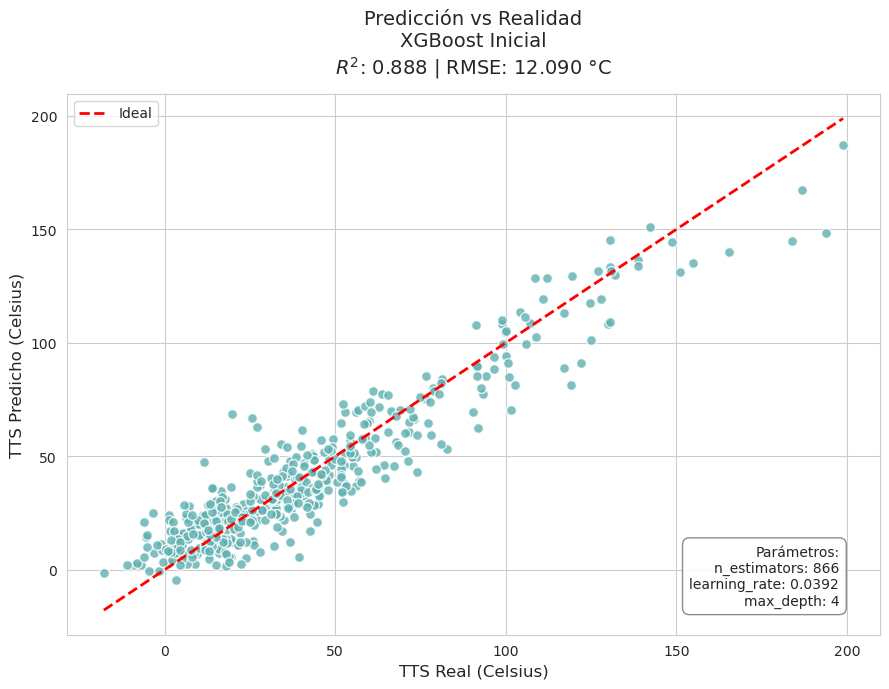

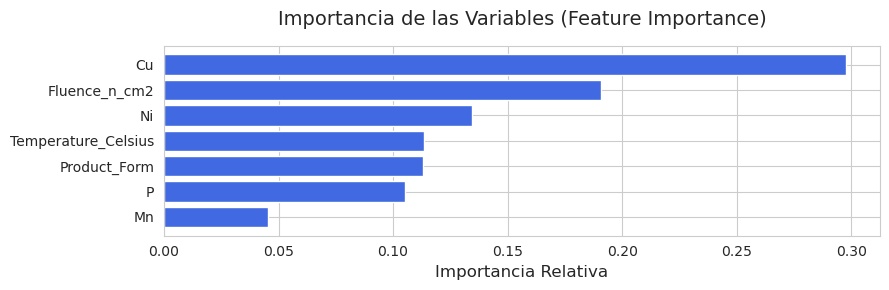

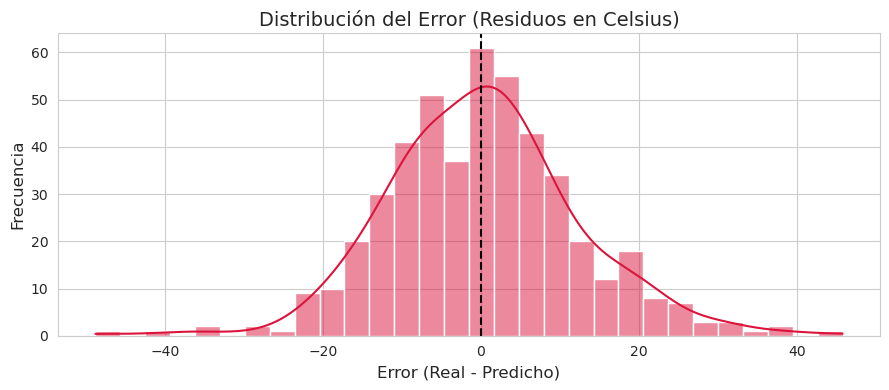

In [6]:
# Necesitamos obtener las predicciones en la escala del modelo (0 a 1 o normalizadas)
preds_scaled = final_model.predict(X_test)

# Usamos el escalador entrenado previamente
scaler = preprocessor 

# Buscamos el índice de la columna target ('DT41J_Celsius') para des-escalar correctamente
target_col_name = 'DT41J_Celsius'
preds_real = dataset.inverse_transform_y(preds_scaled, target_col=target_col_name, preprocessor=scaler)
y_test_real = dataset.inverse_transform_y(y_test, target_col=target_col_name, preprocessor=scaler)

metricas = final_model.evaluate(
    X_test, 
    y_test, 
    dataset=dataset, 
    preprocessor=scaler
)
# --- 1. GRÁFICA DE PREDICCIÓN VS REALIDAD ---
plt.figure(figsize=(9, 7))
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '-', 'grid.alpha': 0.3})

# Scatter plot con la estética solicitada
plt.scatter(y_test_real, preds_real, 
            color='#5fb0b0', edgecolor='white', alpha=0.8, s=50)

# Línea de referencia ideal (Error 0)
lims = [min(y_test_real.min(), preds_real.min()), max(y_test_real.max(), preds_real.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Ideal')

# Título y etiquetas
plt.title(f"Predicción vs Realidad\nXGBoost Inicial\n$R^2$: {metricas['r2']:.3f} | RMSE: {metricas['rmse']:.3f} °C", fontsize=14, pad=15)
plt.xlabel("TTS Real (Celsius)", fontsize=12)
plt.ylabel("TTS Predicho (Celsius)", fontsize=12)
plt.legend(loc='upper left')

# Extraemos los parámetros de tu modelo XGBoost
params = final_model.model.get_params()

# Formateamos el texto (seleccionamos los más relevantes para no saturar el gráfico)
texto_params = (
    "Parámetros:\n"
    f"n_estimators: {params.get('n_estimators', 'N/A')}\n"
    f"learning_rate: {round(params.get('learning_rate', 'N/A'), 5)}\n"
    f"max_depth: {params.get('max_depth', 'N/A')}"
)

# Añadimos la caja de texto en la esquina inferior derecha
# x=0.95, y=0.05 son coordenadas relativas a los ejes (0 a 1)
plt.text(0.95, 0.05, texto_params,
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.savefig("../data/img/01_pred_vs_real_xgboost_inicial.png", dpi=300)
plt.show()

# --- 2. IMPORTANCIA DE LAS VARIABLES ---
feature_names = [c for c in dataset.data.columns if c != target_col_name]
importances = final_model.model.feature_importances_

# Ordenamos de menor a mayor para que el barh los dibuje correctamente
indices = np.argsort(importances)

plt.figure(figsize=(9, 3))
plt.barh(range(len(indices)), importances[indices], color='royalblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Importancia de las Variables (Feature Importance)", fontsize=14, pad=15)
plt.xlabel("Importancia Relativa", fontsize=12)

plt.tight_layout()
plt.show()

# --- 3. ANÁLISIS DE RESIDUOS ---
plt.figure(figsize=(9, 4))
residuos = y_test_real - preds_real
sns.histplot(residuos, kde=True, color='crimson', bins=30)
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribución del Error (Residuos en Celsius)", fontsize=14)
plt.xlabel("Error (Real - Predicho)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

plt.tight_layout()
plt.show()

## 3. Discusión

Volviendo a la primera libreta `00_Baseline.ipynb`, se obtiene un RMSE inferior
al obtenido por este modelo de aprendizaje inicial. A continuación se adjuntan 
imágenes representativas de ambos modelos.

<p align="center">
  <img src="../data/img/00_prediccion_realidad_eqn_fisica.png" width="49%" />
  <img src="../data/img/01_pred_vs_real_xgboost_inicial.png?v=2" width="49%" />
</p>